<a href="https://colab.research.google.com/github/eliasdengo/Python-practice-from-beginning-to-advance/blob/Eliasrepos/medical_insurance_cost_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

importing dependence

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn import metrics
import pickle

data collection

In [2]:
insurance_data=pd.read_csv('/content/sample_data/insurance.csv')

In [3]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [4]:
insurance_data.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603


In [5]:
insurance_data.shape

(1338, 7)

In [6]:
insurance_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [7]:
insurance_data.isnull().sum()

,0
age,0
sex,0
bmi,0
children,0
smoker,0
region,0
charges,0


category of data
- sex
- smoker
- region

Data Analysis

In [8]:
# statstical information
insurance_data.describe()

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


/tmp/ipykernel_2721/1228945838.py:4: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(insurance_data['age'])


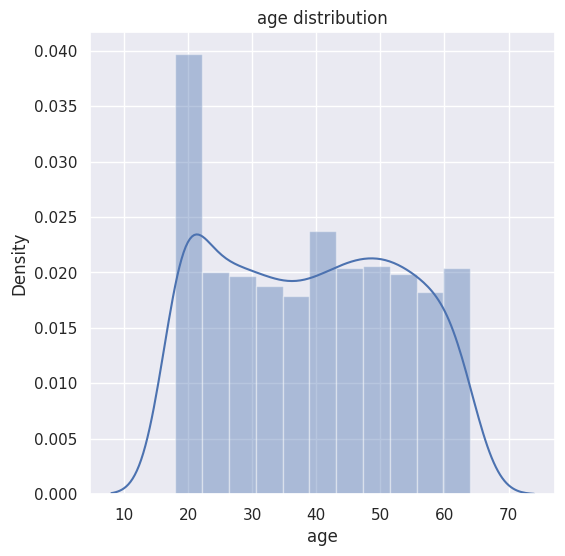

In [9]:
# distribution of age
sns.set()
plt.figure(figsize=(6,6))
sns.distplot(insurance_data['age'])
plt.title('age distribution')
plt.show()

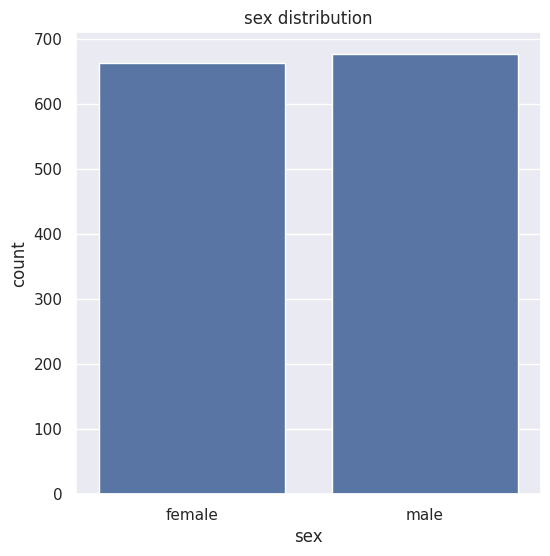

In [10]:
# count ploit of sex
plt.figure(figsize=(6,6))
sns.countplot(x='sex',data=insurance_data)
plt.title('sex distribution')
plt.show()

In [11]:
insurance_data['sex'].value_counts()

,count
sex,
male,676
female,662


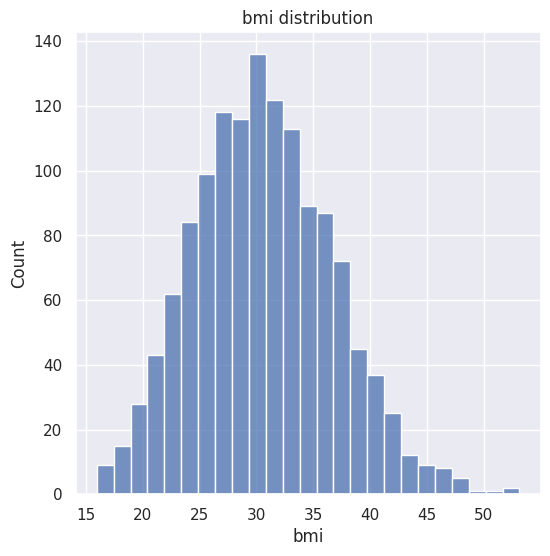

In [12]:
# Distribution of BMI
plt.figure(figsize=(6,6))
sns.histplot(insurance_data['bmi'])
plt.title('bmi distribution')
plt.show()

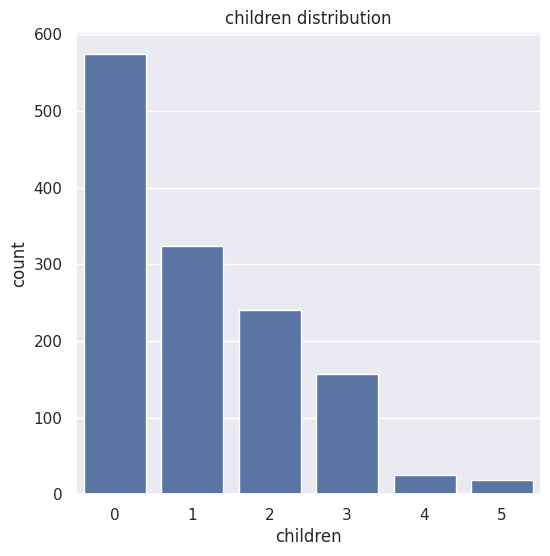

In [13]:
# count ploit of childern
plt.figure(figsize=(6,6))
sns.countplot(x='children',data=insurance_data)
plt.title('children distribution')
plt.show()

In [14]:
insurance_data['children'].value_counts()

,count
children,
0,574
1,324
2,240
3,157
4,25
5,18


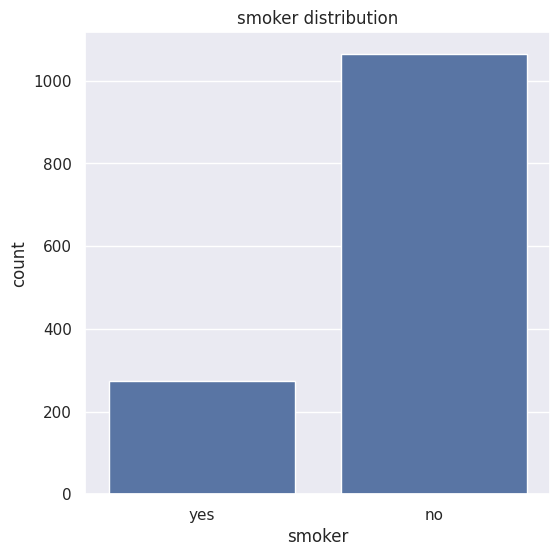

In [15]:
# count ploit of smoke or not
plt.figure(figsize=(6,6))
sns.countplot(x='smoker',data=insurance_data)
plt.title('smoker distribution')
plt.show()

In [16]:
insurance_data['smoker'].value_counts()

,count
smoker,
no,1064
yes,274


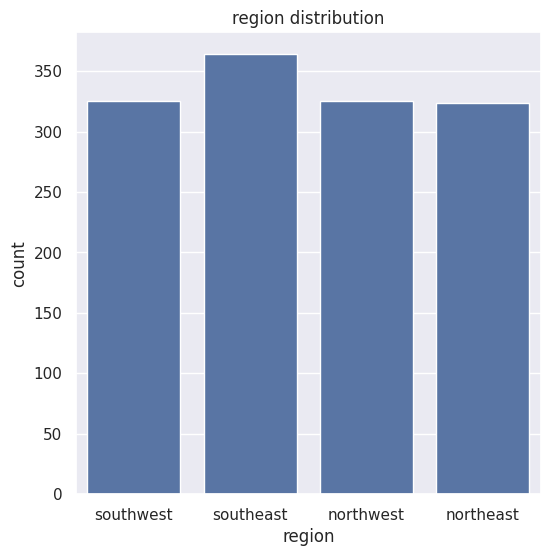

In [17]:
# count ploit of region
plt.figure(figsize=(6,6))
sns.countplot(x='region',data=insurance_data)
plt.title('region distribution')
plt.show()


In [18]:
insurance_data['region'].value_counts()


,count
region,
southeast,364
southwest,325
northwest,325
northeast,324


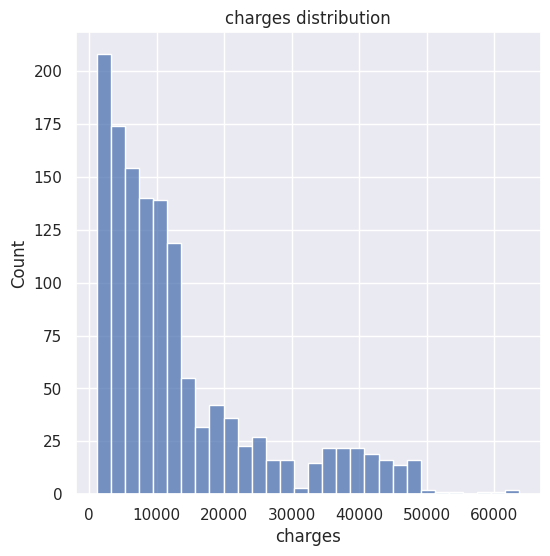

In [19]:
# distribution of charge value
plt.figure(figsize=(6,6))
sns.histplot(insurance_data['charges'])
plt.title('charges distribution')
plt.show()

In [20]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


data pre processing

In [21]:
# encoding data of sex,smoker and region
insurance_data.replace({'sex':{'male':0,'female':1}},inplace=True)
insurance_data.replace({'smoker':{'yes':0,'no':1}},inplace=True)
insurance_data.replace({'region':{'southeast':0,'southwest':1,'northeast':2,'northwest':3}},inplace=True)



/tmp/ipykernel_2721/1388680955.py:2: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'sex':{'male':0,'female':1}},inplace=True)
/tmp/ipykernel_2721/1388680955.py:3: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  insurance_data.replace({'smoker':{'yes':0,'no':1}},inplace=True)
/tmp/ipykernel_2721/1388680955.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the 

In [22]:
insurance_data.head()

,age,sex,bmi,children,smoker,region,charges
0,19,1,27.900,0,0,1,16884.92400
1,18,0,33.770,1,1,0,1725.55230
2,28,0,33.000,3,1,0,4449.46200
3,33,0,22.705,0,1,3,21984.47061
4,32,0,28.880,0,1,3,3866.85520


spilting data in to feature and target

In [23]:
# spilting data into feature and target
x=insurance_data.drop(columns='charges',axis=1)
y=insurance_data['charges']

In [24]:
print(x)

      age  sex     bmi  children  smoker  region
0      19    1  27.900         0       0       1
1      18    0  33.770         1       1       0
2      28    0  33.000         3       1       0
3      33    0  22.705         0       1       3
4      32    0  28.880         0       1       3
...   ...  ...     ...       ...     ...     ...
1333   50    0  30.970         3       1       3
1334   18    1  31.920         0       1       2
1335   18    1  36.850         0       1       0
1336   21    1  25.800         0       1       1
1337   61    1  29.070         0       0       3

[1338 rows x 6 columns]


In [25]:
print(y)

0       16884.92400
1        1725.55230
2        4449.46200
3       21984.47061
4        3866.85520
           ...     
1333    10600.54830
1334     2205.98080
1335     1629.83350
1336     2007.94500
1337    29141.36030
Name: charges, Length: 1338, dtype: float64


spilting data into trainin data and test data

In [26]:
# spilting data into training and test data
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=2)

In [27]:
print(x.shape,x_train.shape,x_test.shape)

(1338, 6) (1070, 6) (268, 6)


Model training

In [28]:
# MODEL LOADING
regression=LinearRegression()

In [29]:
regression.fit(x_train,y_train)

LinearRegression()

In [30]:
training_model=regression.predict(x_train)

MODEL EVALUATION

In [31]:
# r2 MODEL EVALUATION for training
training_model=metrics.r2_score(y_train,training_model)


In [32]:
print(training_model)

0.751505643411174


In [33]:
# r2 model evaluation for test
test_model=regression.predict(x_test)
test_model=metrics.r2_score(y_test,test_model)

In [34]:
print(test_model)

0.7447273869684076


Building prediction system

In [35]:
# building prediction system
input_data=(62,1,26.29,0,0,0)
# change to numpy arrray
input_data_to_numpy_array=np.asarray(input_data)
# reshape array
input_data_reshaped=input_data_to_numpy_array.reshape(1,-1)



In [36]:
prediction_data=regression.predict(input_data_reshaped)
print(prediction_data)

[35663.5965722]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LinearRegression was fitted with feature names
  warnings.warn(


In [37]:
# model download with pickle
with open('medical_insurance_model.pkl','wb') as files:
  pickle.dump(regression,files)